In [1]:
import numpy as np
import yfinance as yf
import pandas as pd
# import matplotlib.pyplot as plt

In [2]:
import yfinance as yf

tickers = ["^GSPC", "^IXIC", "^VIX"]

data = yf.download(
    tickers,
    start="2010-01-01",
    end="2023-01-01",
    auto_adjust=True
)

data.head()

[*********************100%***********************]  3 of 3 completed


Price             Close                                 High               \
Ticker            ^GSPC        ^IXIC       ^VIX        ^GSPC        ^IXIC   
Date                                                                        
2010-01-04  1132.989990  2308.419922  20.040001  1133.869995  2311.149902   
2010-01-05  1136.520020  2308.709961  19.350000  1136.630005  2313.729980   
2010-01-06  1137.140015  2301.090088  19.160000  1139.189941  2314.070068   
2010-01-07  1141.689941  2300.050049  19.059999  1142.459961  2301.300049   
2010-01-08  1144.979980  2317.169922  18.129999  1145.390015  2317.600098   

Price                          Low                                 Open  \
Ticker           ^VIX        ^GSPC        ^IXIC       ^VIX        ^GSPC   
Date                                                                      
2010-01-04  21.680000  1116.560059  2294.409912  20.030001  1116.560059   
2010-01-05  20.129999  1129.660034  2295.620117  19.340000  1132.660034   
2010-01-06  19.680000  1133.949951  2295.679932  18.770000  1135.709961   
2010-01-07  19.709999  1131.319946  2285.219971  18.700001  1136.270020   
2010-01-08  19.270000  1136.219971  2290.610107  18.110001  1140.520020   

Price                                   Volume                   
Ticker            ^IXIC       ^VIX       ^GSPC       ^IXIC ^VIX  
Date                                                             
2010-01-04  2294.409912  21.680000  3991400000  1931380000    0  
2010-01-05  2307.270020  20.049999  2491020000  2367860000    0  
2010-01-06  2307.709961  19.590000  4972660000  2253340000    0  
2010-01-07  2298.090088  19.680000  5270680000  2270050000    0  
2010-01-08  2292.239990  19.270000  4389590000  2145390000    0

In [3]:
close = data["Close"]

close.head()

Ticker,^GSPC,^IXIC,^VIX
Date,,,
2010-01-04,1132.989990,2308.419922,20.040001
2010-01-05,1136.520020,2308.709961,19.350000
2010-01-06,1137.140015,2301.090088,19.160000
2010-01-07,1141.689941,2300.050049,19.059999
2010-01-08,1144.979980,2317.169922,18.129999


In [4]:
close = close.rename(columns={
    "^GSPC": "SP500",
    "^IXIC": "NASDAQ",
    "^VIX": "VIX"
})

close.head()

Ticker,SP500,NASDAQ,VIX
Date,,,
2010-01-04,1132.989990,2308.419922,20.040001
2010-01-05,1136.520020,2308.709961,19.350000
2010-01-06,1137.140015,2301.090088,19.160000
2010-01-07,1141.689941,2300.050049,19.059999
2010-01-08,1144.979980,2317.169922,18.129999


In [5]:
close.columns

Index(['SP500', 'NASDAQ', 'VIX'], dtype='object', name='Ticker')

In [6]:
df = close['SP500']

In [7]:
df = df.to_frame()

In [8]:
df.columns

Index(['SP500'], dtype='object')

In [9]:
df["Ret_1d"] = np.log(df['SP500'] / df['SP500'].shift(1))
df["RV_1d"] = df["Ret_1d"] ** 2

df["RV_lag_1"] = df["RV_1d"].shift(1)
df["RV_mean_5"] = df["RV_1d"].shift(1).rolling(5).mean()
df["RV_mean_22"] = df["RV_1d"].shift(1).rolling(22).mean()

In [10]:
df["RV_forward_5"] = (
    df["RV_1d"].shift(-1)
    + df["RV_1d"].shift(-2)
    + df["RV_1d"].shift(-3)
    + df["RV_1d"].shift(-4)
    + df["RV_1d"].shift(-5)
) / 5

In [12]:
features = ["RV_lag_1", "RV_mean_5", "RV_mean_22"]
target = "RV_forward_5"

model_df = df[[target] + features].dropna()

X = model_df[features]
y = model_df[target]
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

split_idx = int(len(model_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

model.fit(X_train, y_train)

y_test_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2:", r2_score(y_test, y_test_pred))

MSE: 2.3968912911748964e-08
RMSE: 0.00015481896819107458
R2: -0.026149367765600617


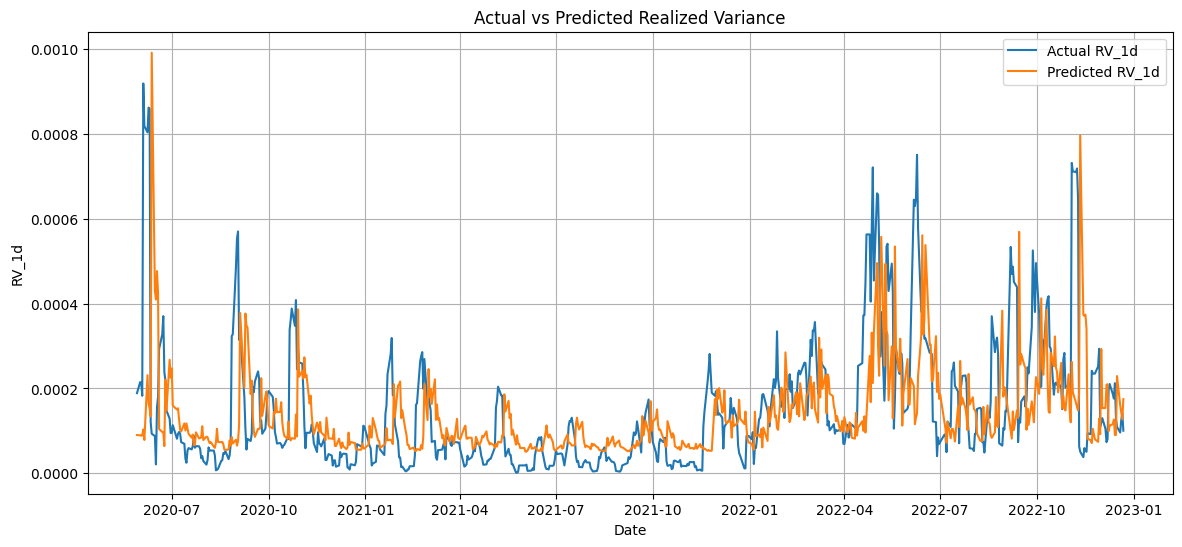

In [13]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(14, 6))

plt.plot(y_test.index, y_test, label="Actual RV_1d")
plt.plot(y_test.index, y_test_pred, label="Predicted RV_1d")

plt.title("Actual vs Predicted Realized Variance")
plt.xlabel("Date")
plt.ylabel("RV_1d")
plt.legend()
plt.grid(True)

plt.show()

Here we wanna to add some jumping to our model as we can see on th e picture below our HAR model is, "lagging and the spikes seems to be not fawvourable at all


In [14]:
eps = 1e-12

df["Ret_1d"] = np.log(df["SP500"] / df["SP500"].shift(1))
df["RV_1d"] = df["Ret_1d"] ** 2

df["RV_lag_1"] = df["RV_1d"].shift(1)
df["RV_mean_5"] = df["RV_1d"].shift(1).rolling(5).mean()
df["RV_mean_22"] = df["RV_1d"].shift(1).rolling(22).mean()

df["vol_jump_signal"] = df["RV_mean_5"] / (df["RV_mean_22"] + eps)
df["jump_regime"] = (df["vol_jump_signal"] > 2).astype(int)

df["RV_lag_1_jump"] = df["RV_lag_1"] * df["jump_regime"]
df["RV_mean_5_jump"] = df["RV_mean_5"] * df["jump_regime"]
df["RV_mean_22_jump"] = df["RV_mean_22"] * df["jump_regime"]

df["RV_forward_5"] = sum(
    df["RV_1d"].shift(-i) for i in range(1, 6)
) / 5

# df["log_RV_forward_5"] = np.log(df["RV_forward_5"] + eps)

In [15]:
features = [
    "RV_lag_1",
    "RV_mean_5",
    "RV_mean_22",
    "vol_jump_signal",
    "jump_regime",
    "RV_lag_1_jump",
    "RV_mean_5_jump",
    "RV_mean_22_jump",
]

target = "RV_forward_5"

In [16]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model_df = df[[target] + features].dropna()

X = model_df[features]
y = model_df[target]

split_idx = int(len(model_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

model.fit(X_train, y_train)

y_test_pred_log = model.predict(X_test)

y_test_pred = np.exp(y_test_pred_log) - eps
y_test_original = np.exp(y_test) - eps

print("RMSE:", np.sqrt(mean_squared_error(y_test_original, y_test_pred)))
print("R2:", r2_score(y_test_original, y_test_pred))

RMSE: 0.00018994272804833415
R2: -0.543625699067946


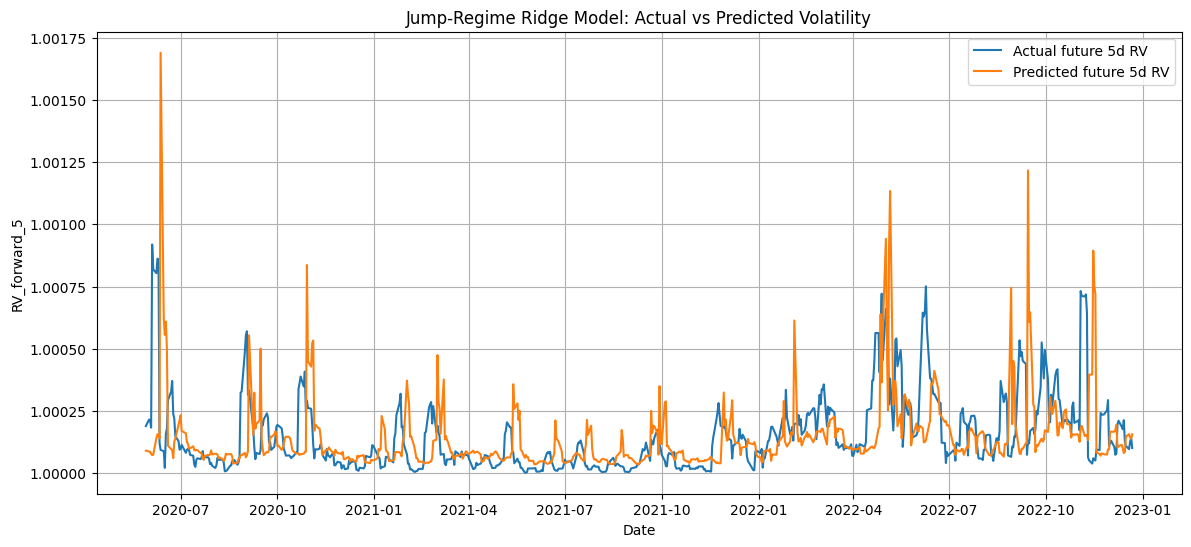

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(y_test.index, y_test_original, label="Actual future 5d RV")
plt.plot(y_test.index, y_test_pred, label="Predicted future 5d RV")

plt.title("Jump-Regime Ridge Model: Actual vs Predicted Volatility")
plt.xlabel("Date")
plt.ylabel("RV_forward_5")
plt.legend()
plt.grid(True)

plt.show()

In [19]:
import pymc as pm
import arviz as az
az.summary(trace, var_names=["alpha", "beta", "sigma"])

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


NameError: name 'trace' is not defined

Now let's us play a little witha vix


In [21]:
df = close['VIX']
df = df.to_frame()

In [22]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3272 entries, 2010-01-04 to 2022-12-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   VIX     3272 non-null   float64
dtypes: float64(1)
memory usage: 51.1 KB


In [23]:
df["Ret_1d"] = np.log(df['VIX'] / df['VIX'].shift(1))
df["RV_1d"] = df["Ret_1d"] ** 2

df["RV_lag_1"] = df["RV_1d"].shift(1)
df["RV_mean_5"] = df["RV_1d"].shift(1).rolling(5).mean()
df["RV_mean_22"] = df["RV_1d"].shift(1).rolling(22).mean()

In [27]:
df["RV_forward_5"] = (
    df["RV_1d"].shift(-1)
    + df["RV_1d"].shift(-2)
    + df["RV_1d"].shift(-3)
    + df["RV_1d"].shift(-4)
    + df["RV_1d"].shift(-5)
) / 5

In [26]:
features = ["RV_lag_1", "RV_mean_5", "RV_mean_22"]
target = "RV_forward_5"

model_df = df[[target] + features].dropna()

X = model_df[features]
y = model_df[target]
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

split_idx = int(len(model_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

model.fit(X_train, y_train)

y_test_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2:", r2_score(y_test, y_test_pred))

MSE: 6.828780723462725e-05
RMSE: 0.008263643702061898
R2: -0.007561487192624394


In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

features = ["RV_lag_1", "RV_mean_5", "RV_mean_22"]
target = "RV_forward_5"

model_df = df[[target] + features].dropna()

X = model_df[features]
y = model_df[target]

model = LinearRegression()
model.fit(X, y)

y_fitted = model.predict(X)

print("Intercept:", model.intercept_)

for name, coef in zip(features, model.coef_):
    print(f"{name}: {coef}")

print("\nIn-sample metrics")
print("MSE:", mean_squared_error(y, y_fitted))
print("RMSE:", np.sqrt(mean_squared_error(y, y_fitted)))
print("R2:", r2_score(y, y_fitted))

Intercept: 0.005062281515515207
RV_lag_1: 0.02882538202545158
RV_mean_5: 0.15427530496335162
RV_mean_22: -0.0027186395723180837

In-sample metrics
MSE: 9.31083493253947e-05
RMSE: 0.009649266776568815
R2: 0.03465775776560431


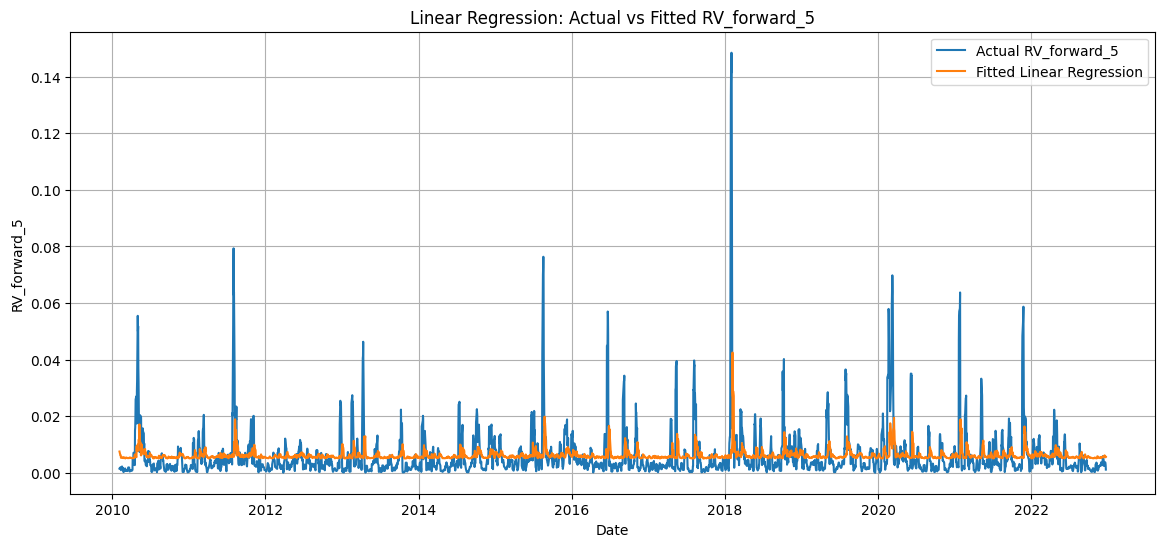

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(y.index, y, label="Actual RV_forward_5")
plt.plot(y.index, y_fitted, label="Fitted Linear Regression")

plt.title("Linear Regression: Actual vs Fitted RV_forward_5")
plt.xlabel("Date")
plt.ylabel("RV_forward_5")
plt.legend()
plt.grid(True)

plt.show()

               model  RMSE_log   MAE_log    R2_log   RMSE_RV   MAE_RV  \
0    OLS HAR log(RV)  0.973811  0.765658  0.239203  0.000153  0.00009   
1  Ridge HAR log(RV)  0.973820  0.765673  0.239190  0.000153  0.00009   

      R2_RV     QLIKE  
0 -0.002227  0.682492  
1 -0.002313  0.682515  

OLS intercept: -2.9384714796351803
          feature  coefficient
0    log_RV_lag_1     0.022832
1   log_RV_mean_5     0.320375
2  log_RV_mean_22     0.370478


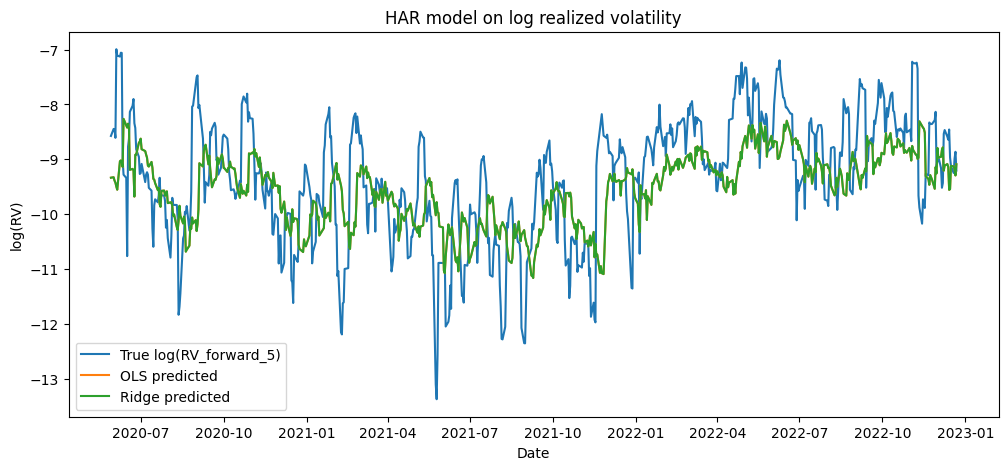


Correlations:
                  log_RV_forward_5  log_RV_lag_1  log_RV_mean_5  \
log_RV_forward_5          1.000000      0.321109       0.565861   
log_RV_lag_1              0.321109      1.000000       0.506812   
log_RV_mean_5             0.565861      0.506812       1.000000   
log_RV_mean_22            0.565439      0.370775       0.764973   

                  log_RV_mean_22  
log_RV_forward_5        0.565439  
log_RV_lag_1            0.370775  
log_RV_mean_5           0.764973  
log_RV_mean_22          1.000000  


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def qlike(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    y_true = np.maximum(y_true, eps)
    y_pred = np.maximum(y_pred, eps)

    return np.mean(y_true / y_pred - np.log(y_true / y_pred) - 1)


df = df.copy()

eps = 1e-12

# Returns and realized variance
df["Ret_1d"] = np.log(df["SP500"] / df["SP500"].shift(1))
df["RV_1d"] = df["Ret_1d"] ** 2

# HAR features
df["RV_lag_1"] = df["RV_1d"].shift(1)

df["RV_mean_5"] = (
    df["RV_1d"]
    .shift(1)
    .rolling(window=5)
    .mean()
)

df["RV_mean_22"] = (
    df["RV_1d"]
    .shift(1)
    .rolling(window=22)
    .mean()
)

# Forward target: mean RV from t+1 to t+5
df["RV_forward_5"] = (
    df["RV_1d"]
    .shift(-1)
    .rolling(window=5)
    .mean()
    .shift(-4)
)

# Log-transform
df["log_RV_lag_1"] = np.log(df["RV_lag_1"] + eps)
df["log_RV_mean_5"] = np.log(df["RV_mean_5"] + eps)
df["log_RV_mean_22"] = np.log(df["RV_mean_22"] + eps)
df["log_RV_forward_5"] = np.log(df["RV_forward_5"] + eps)

features = [
    "log_RV_lag_1",
    "log_RV_mean_5",
    "log_RV_mean_22"
]

target = "log_RV_forward_5"

model_df = df[features + [target, "RV_forward_5"]].dropna()

X = model_df[features]
y = model_df[target]

# Chronological split
split_idx = int(len(model_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

model_df_test = model_df.iloc[split_idx:]

rv_true = model_df_test["RV_forward_5"].values

# OLS
ols = LinearRegression()
ols.fit(X_train, y_train)

y_pred_log_ols = ols.predict(X_test)
rv_pred_ols = np.exp(y_pred_log_ols)

# Ridge
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_pred_log_ridge = ridge_model.predict(X_test)
rv_pred_ridge = np.exp(y_pred_log_ridge)

# Metrics
results = pd.DataFrame({
    "model": ["OLS HAR log(RV)", "Ridge HAR log(RV)"],

    "RMSE_log": [
        np.sqrt(mean_squared_error(y_test, y_pred_log_ols)),
        np.sqrt(mean_squared_error(y_test, y_pred_log_ridge))
    ],

    "MAE_log": [
        mean_absolute_error(y_test, y_pred_log_ols),
        mean_absolute_error(y_test, y_pred_log_ridge)
    ],

    "R2_log": [
        r2_score(y_test, y_pred_log_ols),
        r2_score(y_test, y_pred_log_ridge)
    ],

    "RMSE_RV": [
        np.sqrt(mean_squared_error(rv_true, rv_pred_ols)),
        np.sqrt(mean_squared_error(rv_true, rv_pred_ridge))
    ],

    "MAE_RV": [
        mean_absolute_error(rv_true, rv_pred_ols),
        mean_absolute_error(rv_true, rv_pred_ridge)
    ],

    "R2_RV": [
        r2_score(rv_true, rv_pred_ols),
        r2_score(rv_true, rv_pred_ridge)
    ],

    "QLIKE": [
        qlike(rv_true, rv_pred_ols),
        qlike(rv_true, rv_pred_ridge)
    ]
})

print(results)

# Coefficients OLS
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": ols.coef_
})

print("\nOLS intercept:", ols.intercept_)
print(coef_df)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label="True log(RV_forward_5)")
plt.plot(y_test.index, y_pred_log_ols, label="OLS predicted")
plt.plot(y_test.index, y_pred_log_ridge, label="Ridge predicted")
plt.legend()
plt.title("HAR model on log realized volatility")
plt.xlabel("Date")
plt.ylabel("log(RV)")
plt.show()

# Correlation check
print("\nCorrelations:")
print(model_df[[target] + features].corr())

In [37]:
y_pred_naive = X_test["log_RV_mean_5"]

In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

naive_preds = {
    "Naive log_RV_lag_1": X_test["log_RV_lag_1"],
    "Naive log_RV_mean_5": X_test["log_RV_mean_5"],
    "Naive log_RV_mean_22": X_test["log_RV_mean_22"],
}

for name, pred in naive_preds.items():
    print(name)
    print("RMSE_log:", np.sqrt(mean_squared_error(y_test, pred)))
    print("MAE_log: ", mean_absolute_error(y_test, pred))
    print("R2_log:  ", r2_score(y_test, pred))
    print()

Naive log_RV_lag_1
RMSE_log: 2.4402176133665345
MAE_log:  1.8099606748532528
R2_log:   -3.7772334193002672

Naive log_RV_mean_5
RMSE_log: 1.1568848556142768
MAE_log:  0.8960975676355325
R2_log:   -0.0737412025272608

Naive log_RV_mean_22
RMSE_log: 1.0128690070185271
MAE_log:  0.7937134103782022
R2_log:   0.17695058365033411



g++ not available, if using conda: `conda install gxx`


Train shape: (2595, 3)
Test shape: (649, 3)

OLS intercept: -2.9384714796351803
          feature  OLS_coefficient
0    log_RV_lag_1         0.022832
1   log_RV_mean_5         0.320375
2  log_RV_mean_22         0.370478


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 18 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [y_obs]


...

,model,RMSE_log,MAE_log,R2_log,RMSE_RV,MAE_RV,R2_RV,QLIKE,coverage_80_log,coverage_95_log,avg_width_80_log,avg_width_95_log,coverage_80_RV,coverage_95_RV,avg_width_80_RV,avg_width_95_RV
0,OLS HAR log(RV),0.973811,0.765658,0.239203,0.000153,0.00009,-0.002227,0.682492,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ridge HAR log(RV),0.973820,0.765673,0.239190,0.000153,0.00009,-0.002313,0.682515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Bayesian HAR Normal,0.975616,0.766598,0.236380,0.000153,0.00009,-0.005788,0.685727,0.827427,0.961479,2.663353,4.075818,0.827427,0.961479,0.000307,0.000655
3,Bayesian HAR Student-t,0.970275,0.761373,0.244717,0.000152,0.00009,0.005243,0.674174,0.810478,0.969183,2.559099,4.156616,0.810478,0.969183,0.000292,0.000692



Bayesian HAR Normal posterior summary:


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,-0.0002,0.0158,-0.026,0.025,2481,1547,1.00,0.00032,0.00023
beta[log_RV_lag_1],0.0471,0.0177,0.018,0.076,2048,1489,1.00,0.00039,0.00028
beta[log_RV_mean_5],0.321,0.0256,0.28,0.36,1349,1319,1.00,0.0007,0.00049
beta[log_RV_mean_22],0.287,0.0235,0.25,0.32,1598,1449,1.00,0.00059,0.00042
sigma,0.8056,0.0111,0.79,0.82,2438,1490,1.00,0.00023,0.00016



Bayesian HAR Student-t posterior summary:


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,0.0048,0.015,-0.02,0.028,2308,1431,1.00,0.00031,0.00021
beta[log_RV_lag_1],0.046,0.0174,0.019,0.075,2019,1352,1.00,0.00039,0.00028
beta[log_RV_mean_5],0.318,0.026,0.28,0.36,1128,1250,1.00,0.00078,0.00056
beta[log_RV_mean_22],0.296,0.0241,0.26,0.34,1326,1399,1.00,0.00066,0.00047
sigma,0.7223,0.0158,0.7,0.75,1644,1345,1.00,0.00039,0.00028
nu,10.36,1.93,7.8,14,1642,1467,1.00,0.048,0.044


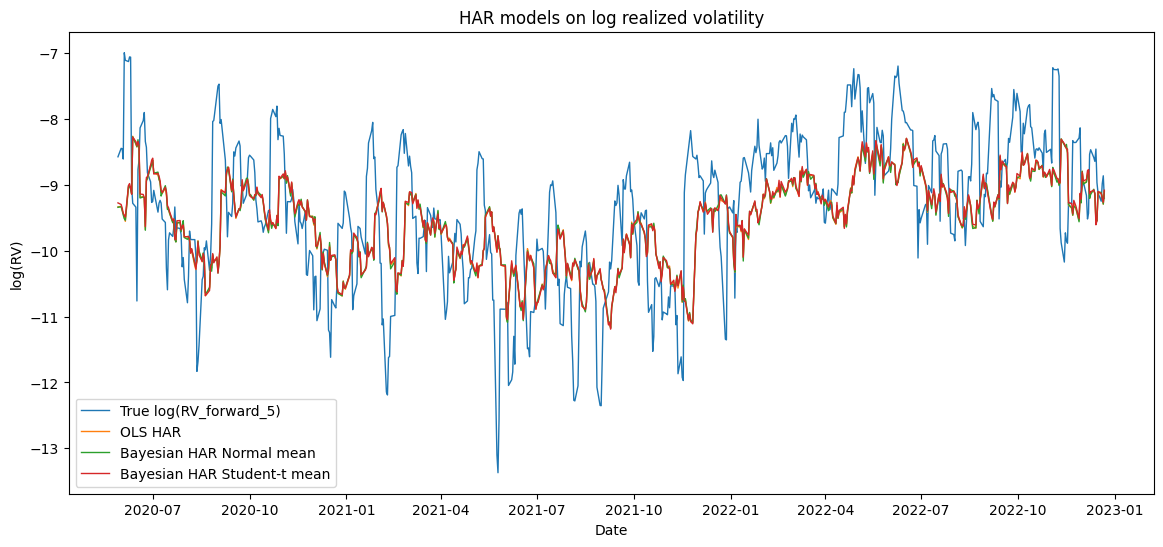

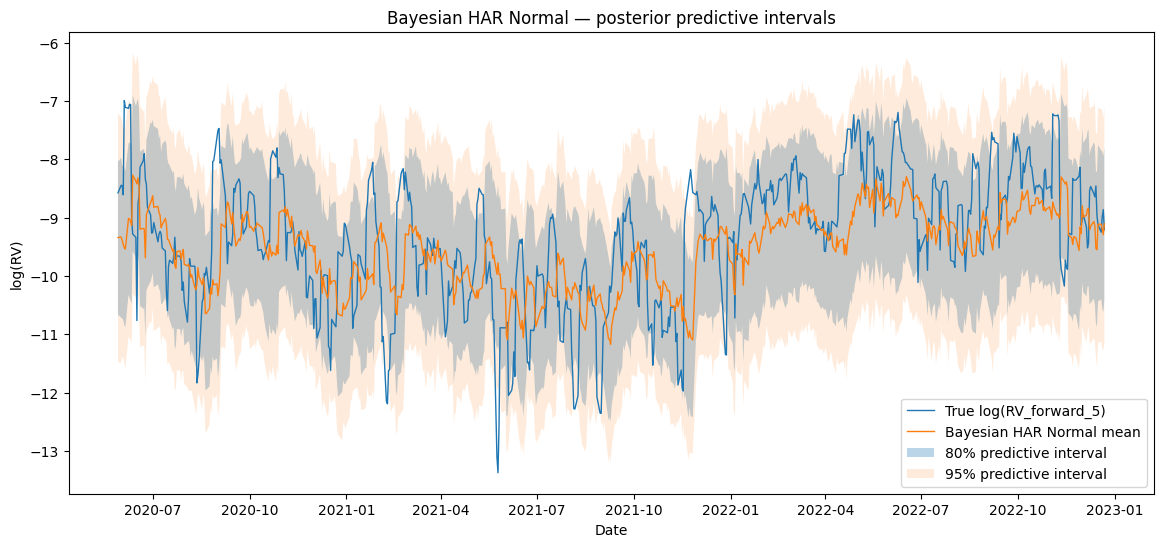

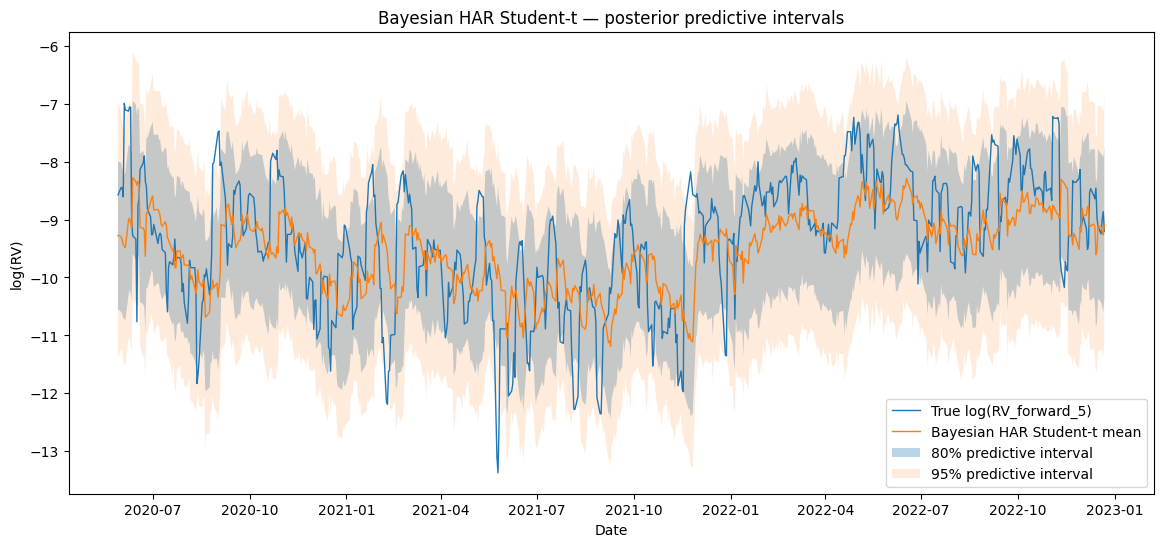

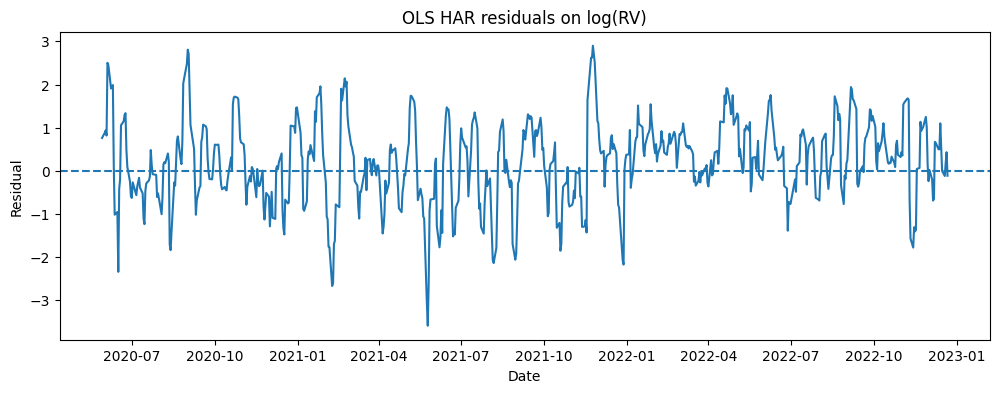

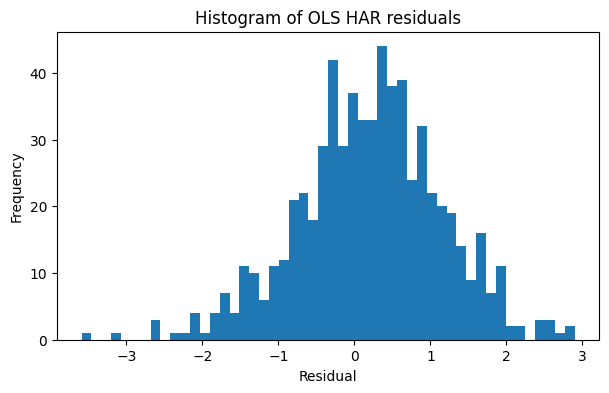


Correlations:


,log_RV_forward_5,log_RV_lag_1,log_RV_mean_5,log_RV_mean_22
log_RV_forward_5,1.000000,0.321109,0.565861,0.565439
log_RV_lag_1,0.321109,1.000000,0.506812,0.370775
log_RV_mean_5,0.565861,0.506812,1.000000,0.764973
log_RV_mean_22,0.565439,0.370775,0.764973,1.000000


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pymc as pm
import arviz as az

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ============================================================
# 1. Helper functions
# ============================================================

def qlike(y_true, y_pred, eps=1e-12):
    """
    QLIKE loss for volatility / variance forecasts.
    Lower is better.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    y_true = np.maximum(y_true, eps)
    y_pred = np.maximum(y_pred, eps)

    return np.mean(y_true / y_pred - np.log(y_true / y_pred) - 1)


def coverage(y_true, lower, upper):
    """
    Empirical coverage of prediction intervals.
    """
    y_true = np.asarray(y_true)
    return np.mean((y_true >= lower) & (y_true <= upper))


def interval_width(lower, upper):
    """
    Average width of prediction intervals.
    """
    return np.mean(upper - lower)


def evaluate_point_model(name, y_true_log, y_pred_log, rv_true):
    """
    Evaluate a point forecast model on both log(RV) and RV scale.
    """
    rv_pred = np.exp(y_pred_log)

    return {
        "model": name,

        "RMSE_log": np.sqrt(mean_squared_error(y_true_log, y_pred_log)),
        "MAE_log": mean_absolute_error(y_true_log, y_pred_log),
        "R2_log": r2_score(y_true_log, y_pred_log),

        "RMSE_RV": np.sqrt(mean_squared_error(rv_true, rv_pred)),
        "MAE_RV": mean_absolute_error(rv_true, rv_pred),
        "R2_RV": r2_score(rv_true, rv_pred),

        "QLIKE": qlike(rv_true, rv_pred),

        "coverage_80_log": np.nan,
        "coverage_95_log": np.nan,
        "avg_width_80_log": np.nan,
        "avg_width_95_log": np.nan,

        "coverage_80_RV": np.nan,
        "coverage_95_RV": np.nan,
        "avg_width_80_RV": np.nan,
        "avg_width_95_RV": np.nan,
    }


def evaluate_bayesian_predictions(name, y_true_log, pred_samples_log, rv_true):
    """
    Evaluate Bayesian posterior predictive samples.

    pred_samples_log shape:
        (n_posterior_samples, n_test_observations)
    """
    pred_mean_log = pred_samples_log.mean(axis=0)

    lower_80_log = np.quantile(pred_samples_log, 0.10, axis=0)
    upper_80_log = np.quantile(pred_samples_log, 0.90, axis=0)

    lower_95_log = np.quantile(pred_samples_log, 0.025, axis=0)
    upper_95_log = np.quantile(pred_samples_log, 0.975, axis=0)

    rv_pred_mean = np.exp(pred_mean_log)

    lower_80_rv = np.exp(lower_80_log)
    upper_80_rv = np.exp(upper_80_log)

    lower_95_rv = np.exp(lower_95_log)
    upper_95_rv = np.exp(upper_95_log)

    results = {
        "model": name,

        "RMSE_log": np.sqrt(mean_squared_error(y_true_log, pred_mean_log)),
        "MAE_log": mean_absolute_error(y_true_log, pred_mean_log),
        "R2_log": r2_score(y_true_log, pred_mean_log),

        "RMSE_RV": np.sqrt(mean_squared_error(rv_true, rv_pred_mean)),
        "MAE_RV": mean_absolute_error(rv_true, rv_pred_mean),
        "R2_RV": r2_score(rv_true, rv_pred_mean),

        "QLIKE": qlike(rv_true, rv_pred_mean),

        "coverage_80_log": coverage(y_true_log, lower_80_log, upper_80_log),
        "coverage_95_log": coverage(y_true_log, lower_95_log, upper_95_log),

        "avg_width_80_log": interval_width(lower_80_log, upper_80_log),
        "avg_width_95_log": interval_width(lower_95_log, upper_95_log),

        "coverage_80_RV": coverage(rv_true, lower_80_rv, upper_80_rv),
        "coverage_95_RV": coverage(rv_true, lower_95_rv, upper_95_rv),

        "avg_width_80_RV": interval_width(lower_80_rv, upper_80_rv),
        "avg_width_95_RV": interval_width(lower_95_rv, upper_95_rv),
    }

    intervals = {
        "pred_mean_log": pred_mean_log,

        "lower_80_log": lower_80_log,
        "upper_80_log": upper_80_log,

        "lower_95_log": lower_95_log,
        "upper_95_log": upper_95_log,

        "rv_pred_mean": rv_pred_mean,

        "lower_80_rv": lower_80_rv,
        "upper_80_rv": upper_80_rv,

        "lower_95_rv": lower_95_rv,
        "upper_95_rv": upper_95_rv,
    }

    return results, intervals


# ============================================================
# 2. Data preparation: HAR features on log(RV)
# ============================================================

df = df.copy()

eps = 1e-12

# Log returns
df["Ret_1d"] = np.log(df["SP500"] / df["SP500"].shift(1))

# Daily realized variance proxy
df["RV_1d"] = df["Ret_1d"] ** 2

# HAR features: only past information
df["RV_lag_1"] = df["RV_1d"].shift(1)

df["RV_mean_5"] = (
    df["RV_1d"]
    .shift(1)
    .rolling(window=5)
    .mean()
)

df["RV_mean_22"] = (
    df["RV_1d"]
    .shift(1)
    .rolling(window=22)
    .mean()
)

# Forward target: average RV over t+1, ..., t+5
df["RV_forward_5"] = (
    df["RV_1d"]
    .shift(-1)
    .rolling(window=5)
    .mean()
    .shift(-4)
)

# Log-transform
df["log_RV_lag_1"] = np.log(df["RV_lag_1"] + eps)
df["log_RV_mean_5"] = np.log(df["RV_mean_5"] + eps)
df["log_RV_mean_22"] = np.log(df["RV_mean_22"] + eps)
df["log_RV_forward_5"] = np.log(df["RV_forward_5"] + eps)

features = [
    "log_RV_lag_1",
    "log_RV_mean_5",
    "log_RV_mean_22"
]

target = "log_RV_forward_5"

model_df = df[features + [target, "RV_forward_5"]].dropna()

X = model_df[features]
y = model_df[target]

# Chronological train/test split
split_idx = int(len(model_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

model_df_test = model_df.iloc[split_idx:]
rv_true = model_df_test["RV_forward_5"].values

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


# ============================================================
# 3. Classical HAR baselines: OLS and Ridge
# ============================================================

ols = LinearRegression()
ols.fit(X_train, y_train)

y_pred_log_ols = ols.predict(X_test)

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_pred_log_ridge = ridge_model.predict(X_test)

ols_results = evaluate_point_model(
    name="OLS HAR log(RV)",
    y_true_log=y_test.values,
    y_pred_log=y_pred_log_ols,
    rv_true=rv_true
)

ridge_results = evaluate_point_model(
    name="Ridge HAR log(RV)",
    y_true_log=y_test.values,
    y_pred_log=y_pred_log_ridge,
    rv_true=rv_true
)

coef_df = pd.DataFrame({
    "feature": features,
    "OLS_coefficient": ols.coef_
})

print("\nOLS intercept:", ols.intercept_)
print(coef_df)


# ============================================================
# 4. Scaling for Bayesian models
# ============================================================

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(
    y_train.values.reshape(-1, 1)
).ravel()

y_test_scaled = y_scaler.transform(
    y_test.values.reshape(-1, 1)
).ravel()

n_features = X_train_scaled.shape[1]


# ============================================================
# 5. Bayesian HAR Normal
# ============================================================

coords_train = {
    "obs_id": np.arange(X_train_scaled.shape[0]),
    "feature": features,
}

with pm.Model(coords=coords_train) as normal_model:
    X_data = pm.Data(
        "X_data",
        X_train_scaled,
        dims=("obs_id", "feature")
    )

    y_data = pm.Data(
        "y_data",
        y_train_scaled,
        dims="obs_id"
    )

    alpha = pm.Normal("alpha", mu=0.0, sigma=1.0)

    beta = pm.Normal(
        "beta",
        mu=0.0,
        sigma=1.0,
        dims="feature"
    )

    sigma = pm.HalfNormal("sigma", sigma=1.0)

    mu = pm.Deterministic(
        "mu",
        alpha + pm.math.dot(X_data, beta),
        dims="obs_id"
    )

    y_obs = pm.Normal(
        "y_obs",
        mu=mu,
        sigma=sigma,
        observed=y_data,
        dims="obs_id"
    )

    normal_idata = pm.sample(
        draws=1000,
        tune=500,
        chains=2,
        target_accept=0.9,
        random_seed=42
    )

with normal_model:
    pm.set_data(
        {
            "X_data": X_test_scaled,
            "y_data": y_test_scaled,
        },
        coords={"obs_id": np.arange(X_test_scaled.shape[0])}
    )

    normal_ppc = pm.sample_posterior_predictive(
        normal_idata,
        var_names=["y_obs"],
        random_seed=42
    )

normal_pred_scaled = normal_ppc.posterior_predictive["y_obs"].values
normal_pred_scaled = normal_pred_scaled.reshape(
    -1,
    normal_pred_scaled.shape[-1]
)

normal_pred_log = y_scaler.inverse_transform(
    normal_pred_scaled.reshape(-1, 1)
).reshape(normal_pred_scaled.shape)

normal_results, normal_intervals = evaluate_bayesian_predictions(
    name="Bayesian HAR Normal",
    y_true_log=y_test.values,
    pred_samples_log=normal_pred_log,
    rv_true=rv_true
)


# ============================================================
# 6. Bayesian HAR Student-t
# ============================================================

coords_train = {
    "obs_id": np.arange(X_train_scaled.shape[0]),
    "feature": features,
}

with pm.Model(coords=coords_train) as student_model:
    X_data = pm.Data(
        "X_data",
        X_train_scaled,
        dims=("obs_id", "feature")
    )

    y_data = pm.Data(
        "y_data",
        y_train_scaled,
        dims="obs_id"
    )

    alpha = pm.Normal("alpha", mu=0.0, sigma=1.0)

    beta = pm.Normal(
        "beta",
        mu=0.0,
        sigma=1.0,
        dims="feature"
    )

    sigma = pm.HalfNormal("sigma", sigma=1.0)

    # nu > 2, so the variance exists
    nu_minus_two = pm.Exponential("nu_minus_two", lam=1 / 10)
    nu = pm.Deterministic("nu", nu_minus_two + 2)

    mu = pm.Deterministic(
        "mu",
        alpha + pm.math.dot(X_data, beta),
        dims="obs_id"
    )

    y_obs = pm.StudentT(
        "y_obs",
        nu=nu,
        mu=mu,
        sigma=sigma,
        observed=y_data,
        dims="obs_id"
    )

    student_idata = pm.sample(
        draws=1000,
        tune=500,
        chains=2,
        target_accept=0.9,
        random_seed=42
    )

with student_model:
    pm.set_data(
        {
            "X_data": X_test_scaled,
            "y_data": y_test_scaled,
        },
        coords={"obs_id": np.arange(X_test_scaled.shape[0])}
    )

    student_ppc = pm.sample_posterior_predictive(
        student_idata,
        var_names=["y_obs"],
        random_seed=42
    )

student_pred_scaled = student_ppc.posterior_predictive["y_obs"].values
student_pred_scaled = student_pred_scaled.reshape(
    -1,
    student_pred_scaled.shape[-1]
)

student_pred_log = y_scaler.inverse_transform(
    student_pred_scaled.reshape(-1, 1)
).reshape(student_pred_scaled.shape)

student_results, student_intervals = evaluate_bayesian_predictions(
    name="Bayesian HAR Student-t",
    y_true_log=y_test.values,
    pred_samples_log=student_pred_log,
    rv_true=rv_true
)


# ============================================================
# 7. Results table
# ============================================================

all_results = pd.DataFrame([
    ols_results,
    ridge_results,
    normal_results,
    student_results
])

display(all_results)

print("\nBayesian HAR Normal posterior summary:")
display(az.summary(normal_idata, var_names=["alpha", "beta", "sigma"]))

print("\nBayesian HAR Student-t posterior summary:")
display(az.summary(student_idata, var_names=["alpha", "beta", "sigma", "nu"]))


# ============================================================
# 8. Plots
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    y_test.index,
    y_test.values,
    label="True log(RV_forward_5)",
    linewidth=1
)

plt.plot(
    y_test.index,
    y_pred_log_ols,
    label="OLS HAR",
    linewidth=1
)

plt.plot(
    y_test.index,
    normal_intervals["pred_mean_log"],
    label="Bayesian HAR Normal mean",
    linewidth=1
)

plt.plot(
    y_test.index,
    student_intervals["pred_mean_log"],
    label="Bayesian HAR Student-t mean",
    linewidth=1
)

plt.title("HAR models on log realized volatility")
plt.xlabel("Date")
plt.ylabel("log(RV)")
plt.legend()
plt.show()


plt.figure(figsize=(14, 6))

plt.plot(
    y_test.index,
    y_test.values,
    label="True log(RV_forward_5)",
    linewidth=1
)

plt.plot(
    y_test.index,
    normal_intervals["pred_mean_log"],
    label="Bayesian HAR Normal mean",
    linewidth=1
)

plt.fill_between(
    y_test.index,
    normal_intervals["lower_80_log"],
    normal_intervals["upper_80_log"],
    alpha=0.3,
    label="80% predictive interval"
)

plt.fill_between(
    y_test.index,
    normal_intervals["lower_95_log"],
    normal_intervals["upper_95_log"],
    alpha=0.15,
    label="95% predictive interval"
)

plt.title("Bayesian HAR Normal — posterior predictive intervals")
plt.xlabel("Date")
plt.ylabel("log(RV)")
plt.legend()
plt.show()


plt.figure(figsize=(14, 6))

plt.plot(
    y_test.index,
    y_test.values,
    label="True log(RV_forward_5)",
    linewidth=1
)

plt.plot(
    y_test.index,
    student_intervals["pred_mean_log"],
    label="Bayesian HAR Student-t mean",
    linewidth=1
)

plt.fill_between(
    y_test.index,
    student_intervals["lower_80_log"],
    student_intervals["upper_80_log"],
    alpha=0.3,
    label="80% predictive interval"
)

plt.fill_between(
    y_test.index,
    student_intervals["lower_95_log"],
    student_intervals["upper_95_log"],
    alpha=0.15,
    label="95% predictive interval"
)

plt.title("Bayesian HAR Student-t — posterior predictive intervals")
plt.xlabel("Date")
plt.ylabel("log(RV)")
plt.legend()
plt.show()


# Residuals from OLS, useful motivation for Student-t likelihood
residuals_ols = y_test.values - y_pred_log_ols

plt.figure(figsize=(12, 4))
plt.plot(y_test.index, residuals_ols)
plt.axhline(0, linestyle="--")
plt.title("OLS HAR residuals on log(RV)")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(residuals_ols, bins=50)
plt.title("Histogram of OLS HAR residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()


# Correlation check
print("\nCorrelations:")
display(model_df[[target] + features].corr())

In [42]:
print(all_results)

                    model  RMSE_log   MAE_log    R2_log   RMSE_RV   MAE_RV  \
0         OLS HAR log(RV)  0.973811  0.765658  0.239203  0.000153  0.00009   
1       Ridge HAR log(RV)  0.973820  0.765673  0.239190  0.000153  0.00009   
2     Bayesian HAR Normal  0.975616  0.766598  0.236380  0.000153  0.00009   
3  Bayesian HAR Student-t  0.970275  0.761373  0.244717  0.000152  0.00009   

      R2_RV     QLIKE  coverage_80_log  coverage_95_log  avg_width_80_log  \
0 -0.002227  0.682492              NaN              NaN               NaN   
1 -0.002313  0.682515              NaN              NaN               NaN   
2 -0.005788  0.685727         0.827427         0.961479          2.663353   
3  0.005243  0.674174         0.810478         0.969183          2.559099   

   avg_width_95_log  coverage_80_RV  coverage_95_RV  avg_width_80_RV  \
0               NaN             NaN             NaN              NaN   
1               NaN             NaN             NaN              NaN   
2      

In [43]:
az.summary(student_idata, var_names=["alpha", "beta", "sigma", "nu"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,0.0048,0.015,-0.02,0.028,2308,1431,1.00,0.00031,0.00021
beta[log_RV_lag_1],0.046,0.0174,0.019,0.075,2019,1352,1.00,0.00039,0.00028
beta[log_RV_mean_5],0.318,0.026,0.28,0.36,1128,1250,1.00,0.00078,0.00056
beta[log_RV_mean_22],0.296,0.0241,0.26,0.34,1326,1399,1.00,0.00066,0.00047
sigma,0.7223,0.0158,0.7,0.75,1644,1345,1.00,0.00039,0.00028
nu,10.36,1.93,7.8,14,1642,1467,1.00,0.048,0.044


In [21]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

signals_df = pd.DataFrame(index=y_test.index)

signals_df["rv_true"] = rv_true
signals_df["ols_pred"] = np.exp(y_pred_log_ols)

signals_df["bayes_mean"] = student_intervals["rv_pred_mean"]
signals_df["bayes_upper_80"] = student_intervals["upper_80_rv"]
signals_df["bayes_upper_95"] = student_intervals["upper_95_rv"]

threshold = np.quantile(model_df["RV_forward_5"], 0.80)

signals_df["high_vol_realized"] = (
    signals_df["rv_true"] > threshold
).astype(int)

signals_df["warning_ols_mean"] = (
    signals_df["ols_pred"] > threshold
).astype(int)

signals_df["warning_bayes_mean"] = (
    signals_df["bayes_mean"] > threshold
).astype(int)

signals_df["warning_bayes_upper_80"] = (
    signals_df["bayes_upper_80"] > threshold
).astype(int)

signals_df["warning_bayes_upper_95"] = (
    signals_df["bayes_upper_95"] > threshold
).astype(int)


def evaluate_warning(name, y_true, y_signal):
    return {
        "signal": name,
        "precision": precision_score(y_true, y_signal, zero_division=0),
        "recall": recall_score(y_true, y_signal, zero_division=0),
        "f1": f1_score(y_true, y_signal, zero_division=0),
        "n_warnings": int(y_signal.sum()),
        "n_high_vol": int(y_true.sum())
    }


warning_results = pd.DataFrame([
    evaluate_warning(
        "OLS mean forecast",
        signals_df["high_vol_realized"],
        signals_df["warning_ols_mean"]
    ),
    evaluate_warning(
        "Bayesian mean forecast",
        signals_df["high_vol_realized"],
        signals_df["warning_bayes_mean"]
    ),
    evaluate_warning(
        "Bayesian upper 80%",
        signals_df["high_vol_realized"],
        signals_df["warning_bayes_upper_80"]
    ),
    evaluate_warning(
        "Bayesian upper 95%",
        signals_df["high_vol_realized"],
        signals_df["warning_bayes_upper_95"]
    ),
])

warning_results

NameError: name 'student_intervals' is not defined

In [45]:
print(warning_results)

                   signal  precision    recall        f1  n_warnings  \
0       OLS mean forecast   0.666667  0.207207  0.316151          69   
1  Bayesian mean forecast   0.676056  0.216216  0.327645          71   
2      Bayesian upper 80%   0.409736  0.909910  0.565035         493   
3      Bayesian upper 95%   0.343307  0.981982  0.508751         635   

   n_high_vol  
0         222  
1         222  
2         222  
3         222  
